# Phase 5 : Random Forest + XGBoost + Imbalance Handling + Model Comparison

In [7]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

In [8]:
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [9]:
print(df.columns.tolist())

['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'churn_flag']


In [10]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [11]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

In [12]:
df["total_services"] = 0

df["total_services"] += (df["phoneservice"] == "Yes").astype(int)

df["total_services"] += (df["multiplelines"] == "Yes").astype(int)

df["total_services"] += (df["internetservice"] != "No").astype(int)

In [13]:
service_columns = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

for col in service_columns:
    df["total_services"] += (df[col] == "Yes").astype(int)

In [14]:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["totalcharges"] / df["tenure"],
    0
)

df["automatic_payment"] = df["paymentmethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)

df["is_month_to_month"] = (
    df["contract"] == "Month-to-month"
).astype(int)

df["has_tech_support"] = (
    df["techsupport"] == "Yes"
).astype(int)

In [15]:
X = df.drop(
    columns=[
        "customerid",
        "churn",
        "churn_flag"
    ]
)

y = df["churn_flag"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
# Understand class imbalance again
y_train.value_counts()

churn_flag
0    4139
1    1495
Name: count, dtype: int64

In [18]:
y_train.value_counts(normalize=True)

churn_flag
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [20]:
# calculate counts:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

print("Non-Churn:", negative_count)
print("Churn:", positive_count)

Non-Churn: 4139
Churn: 1495


In [21]:
# Calculate ratio:
imbalance_ratio = negative_count / positive_count

print("Imbalance ratio:", imbalance_ratio)

Imbalance ratio: 2.768561872909699


In [24]:
# Imports
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression


# 1. Find numeric columns
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()


# 2. Find categorical columns
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# 3. Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)


# 4. Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


# 5. Combine both
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_31324\3373448104.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [25]:
# MODEL 1 — Normal Logistic Regression
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [26]:
clone(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [27]:
# MODEL 2 — Weighted Logistic Regression
balanced_logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [28]:
class_weight="balanced"

In [29]:
# MODEL 3 — Random Forest
from sklearn.ensemble import RandomForestClassifier

In [30]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [31]:
# MODEL 4 — XGBoost
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,

                subsample=0.8,
                colsample_bytree=0.8,

                objective="binary:logistic",

                eval_metric="logloss",

                scale_pos_weight=imbalance_ratio,

                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [32]:
n_estimators=300

In [33]:
learning_rate=0.05

In [34]:
max_depth=4

In [35]:
subsample=0.8

In [36]:
colsample_bytree=0.8

In [37]:
scale_pos_weight=imbalance_ratio

In [38]:
# Create a model dictionary
models = {
    "Logistic Regression": logistic_model,
    "Balanced Logistic Regression": balanced_logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

In [39]:
models.keys()

dict_keys(['Logistic Regression', 'Balanced Logistic Regression', 'Random Forest', 'XGBoost'])

In [40]:
# Build 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
# Define evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [42]:
# Cross-validate all models
cv_results = []

In [44]:
for name, model in models.items():

    print(f"Training: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append(
        {
            "Model": name,

            "Accuracy": scores[
                "test_accuracy"
            ].mean(),

            "Precision": scores[
                "test_precision"
            ].mean(),

            "Recall": scores[
                "test_recall"
            ].mean(),

            "F1": scores[
                "test_f1"
            ].mean(),

            "ROC_AUC": scores[
                "test_roc_auc"
            ].mean(),

            "PR_AUC": scores[
                "test_pr_auc"
            ].mean()
        }
    )

Training: Logistic Regression
Training: Balanced Logistic Regression
Training: Random Forest
Training: XGBoost


In [45]:
# Create comparison table
comparison_df = pd.DataFrame(
    cv_results
)

In [46]:
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.807777,0.673841,0.534448,0.595623,0.847276,0.662971
1,Balanced Logistic Regression,0.750270,0.519337,0.793311,0.627581,0.847236,0.661183
2,Random Forest,0.775294,0.566382,0.652174,0.606222,0.827692,0.616455
3,XGBoost,0.764645,0.539232,0.776589,0.636425,0.844092,0.659947
4,Logistic Regression,0.807777,0.673841,0.534448,0.595623,0.847276,0.662971
5,Balanced Logistic Regression,0.750270,0.519337,0.793311,0.627581,0.847236,0.661183
6,Random Forest,0.775294,0.566382,0.652174,0.606222,0.827692,0.616455
7,XGBoost,0.764645,0.539232,0.776589,0.636425,0.844092,0.659947


In [48]:
# Formtaing
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599


In [49]:
# Sort by ROC-AUC
comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165


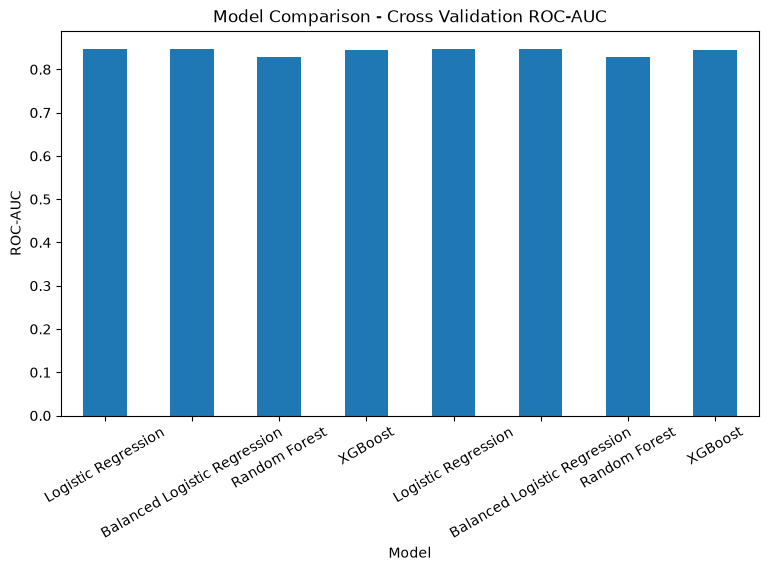

In [50]:
# Visualize model comparison
comparison_df.set_index(
    "Model"
)["ROC_AUC"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Comparison - Cross Validation ROC-AUC"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")

plt.xticks(rotation=30)

plt.show()

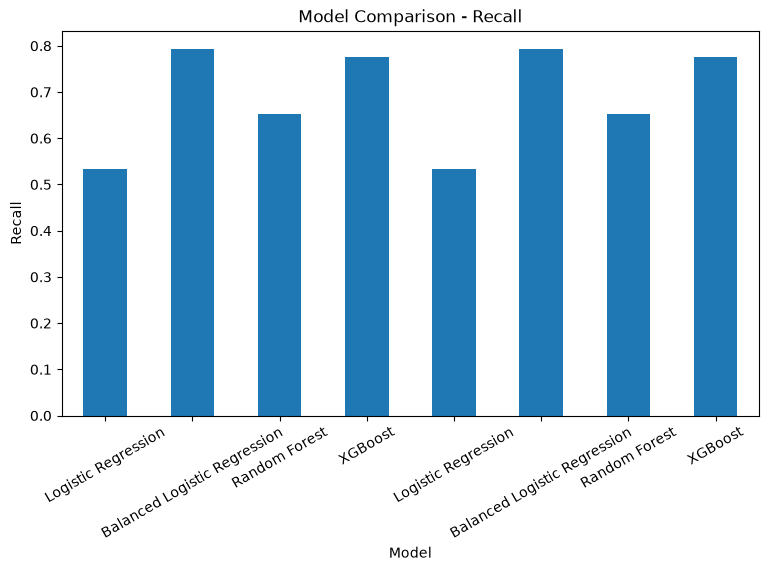

In [51]:
# Recall
comparison_df.set_index(
    "Model"
)["Recall"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Comparison - Recall"
)

plt.ylabel("Recall")

plt.xticks(rotation=30)

plt.show()

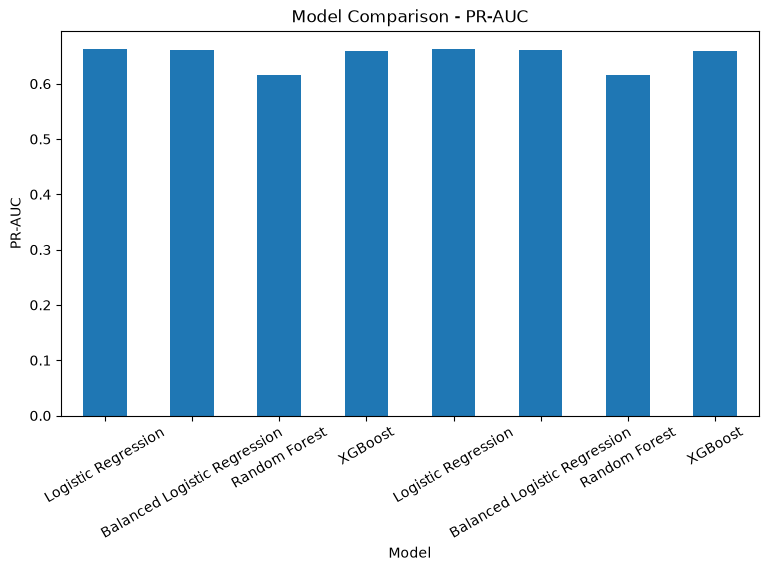

In [52]:
# PR-AUC:
comparison_df.set_index(
    "Model"
)["PR_AUC"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Comparison - PR-AUC"
)

plt.ylabel("PR-AUC")

plt.xticks(rotation=30)

plt.show()

In [53]:
# Compare overfitting for Random Forest
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [55]:
# Training score:
rf_train_pred = random_forest_model.predict(
    X_train
)

print(
    "Training Accuracy:",
    accuracy_score(
        y_train,
        rf_train_pred
    )
)

Training Accuracy: 0.9950301739439119


In [56]:
# XGBoost
xgb_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [57]:
# Training
xgb_train_pred = xgb_model.predict(
    X_train
)

print(
    "XGBoost Training Accuracy:",
    accuracy_score(
        y_train,
        xgb_train_pred
    )
)

XGBoost Training Accuracy: 0.8171813986510472


In [58]:
# Create a better business metric table
business_comparison = comparison_df[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
]

In [59]:
business_comparison.sort_values(
    by="Recall",
    ascending=False
).round(4)

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Balanced Logistic Regression,0.5193,0.7933,0.6276,0.8472,0.6612
5,Balanced Logistic Regression,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.5392,0.7766,0.6364,0.8441,0.6599
6,Random Forest,0.5664,0.6522,0.6062,0.8277,0.6165
2,Random Forest,0.5664,0.6522,0.6062,0.8277,0.6165
0,Logistic Regression,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.6738,0.5344,0.5956,0.8473,0.6630


In [61]:
# Final Test Evaluation
# Set 
final_model = xgb_model

In [62]:
# Fit
final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [63]:
# Predict
y_pred = final_model.predict(
    X_test
)

In [64]:
# Probability
y_prob = final_model.predict_proba(
    X_test
)[:, 1]

In [65]:
# Final metrics
final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred
)

final_recall = recall_score(
    y_test,
    y_pred
)

final_f1 = f1_score(
    y_test,
    y_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob
)

final_pr_auc = average_precision_score(
    y_test,
    y_prob
)

In [66]:
# Print
print(
    "FINAL TEST RESULTS"
)

print(
    "Accuracy :",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall   :",
    round(final_recall, 4)
)

print(
    "F1       :",
    round(final_f1, 4)
)

print(
    "ROC-AUC  :",
    round(final_roc_auc, 4)
)

print(
    "PR-AUC   :",
    round(final_pr_auc, 4)
)

FINAL TEST RESULTS
Accuracy : 0.7601
Precision: 0.5331
Recall   : 0.7754
F1       : 0.6318
ROC-AUC  : 0.8414
PR-AUC   : 0.6529


In [67]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stay",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [68]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[781, 254],
       [ 84, 290]])

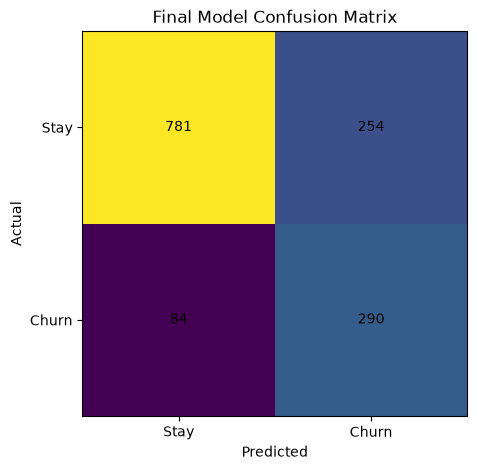

In [69]:
# Visualization :
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Stay",
    "Churn"
])

ax.set_yticklabels([
    "Stay",
    "Churn"
])

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Final Model Confusion Matrix"
)

plt.show()

In [70]:
# Examine the false negatives
error_analysis = X_test.copy()

In [71]:
error_analysis[
    "actual"
] = y_test.values

error_analysis[
    "prediction"
] = y_pred

error_analysis[
    "churn_probability"
] = y_prob

In [72]:
# false negatives:
false_negatives = error_analysis[
    (error_analysis["actual"] == 1)
    &
    (error_analysis["prediction"] == 0)
]

In [73]:
false_negatives[
    [
        "tenure",
        "contract",
        "monthlycharges",
        "internetservice",
        "techsupport",
        "churn_probability"
    ]
].head(20)

,tenure,contract,monthlycharges,internetservice,techsupport,churn_probability
2488,31,Month-to-month,55.25,DSL,Yes,0.225747
523,23,Month-to-month,75.60,Fiber optic,No,0.415592
5086,45,One year,20.40,No,No internet service,0.029805
7011,4,Month-to-month,60.40,DSL,Yes,0.429983
3158,18,Month-to-month,49.55,DSL,No,0.378406
5968,12,One year,74.05,DSL,Yes,0.394794
1577,17,One year,98.60,Fiber optic,Yes,0.276554
1644,34,Month-to-month,109.80,Fiber optic,No,0.309637
1014,18,Month-to-month,57.45,DSL,No,0.419757
3721,2,Month-to-month,20.65,No,No internet service,0.388461


In [74]:
# Look at highest-risk customers
high_risk = error_analysis.sort_values(
    by="churn_probability",
    ascending=False
)

In [75]:
high_risk[
    [
        "tenure",
        "contract",
        "monthlycharges",
        "internetservice",
        "techsupport",
        "paymentmethod",
        "churn_probability",
        "actual"
    ]
].head(20)

,tenure,contract,monthlycharges,internetservice,techsupport,paymentmethod,churn_probability,actual
3380,1,Month-to-month,95.10,Fiber optic,No,Electronic check,0.978952,1
6866,1,Month-to-month,95.45,Fiber optic,No,Electronic check,0.977164,1
4585,1,Month-to-month,85.05,Fiber optic,No,Electronic check,0.968741,1
2631,7,Month-to-month,99.25,Fiber optic,No,Electronic check,0.965758,1
2464,1,Month-to-month,77.15,Fiber optic,No,Electronic check,0.962537,1
6623,1,Month-to-month,76.45,Fiber optic,No,Electronic check,0.959693,1
3346,2,Month-to-month,84.05,Fiber optic,No,Electronic check,0.958486,0
3727,3,Month-to-month,96.60,Fiber optic,No,Electronic check,0.957588,1
2246,1,Month-to-month,102.45,Fiber optic,No,Electronic check,0.957117,1
2753,1,Month-to-month,95.65,Fiber optic,No,Mailed check,0.956014,1


In [76]:
# Risk categories
def risk_category(probability):

    if probability >= 0.80:
        return "Critical"

    elif probability >= 0.60:
        return "High"

    elif probability >= 0.40:
        return "Medium"

    else:
        return "Low"

In [77]:
error_analysis[
    "risk_category"
] = error_analysis[
    "churn_probability"
].apply(risk_category)

In [78]:
error_analysis[
    "risk_category"
].value_counts()

risk_category
Low         766
High        247
Medium      205
Critical    191
Name: count, dtype: int64

In [82]:
# Important: prediction threshold
y_pred = model.predict(X_test)
y_prob[:10]

array([0.01325283, 0.94459796, 0.21215013, 0.4825826 , 0.00999435,
       0.8474409 , 0.72122234, 0.30755588, 0.02025292, 0.6946401 ],
      dtype=float32)

In [83]:
# Save model comparison
comparison_df.to_csv(
    "../artifacts/model_comparison.csv",
    index=False
)